In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

excel_path = Path("/Users/julesschleinitz/Desktop/Code/BNNY/fluoride_modeling_properties_w_experimental_data.xlsx")
required_sheets = ["biox", "box", "pyox"]

if not excel_path.exists():
    raise FileNotFoundError(f"Excel file not found: {excel_path}")


def normalize_sheet(df):
    df = df.copy()
    first_row_values = df.iloc[0].tolist()
    first_row_lower = [str(value).strip().lower() for value in first_row_values]
    if "ddg_flipped" in first_row_lower:
        rename_map = {
            col: first_row_values[idx]
            for idx, col in enumerate(df.columns)
            if not str(col).strip().lower().startswith("x")
        }
        df = df.rename(columns=rename_map)
        df = df.iloc[1:].reset_index(drop=True)
    return df


sheet_frames = {
    sheet_name: normalize_sheet(df)
    for sheet_name, df in pd.read_excel(excel_path, sheet_name=required_sheets).items()
}



def best_xi_correlation(df, sheet_name):
    columns_lower = {str(col).strip().lower(): col for col in df.columns}
    ddg_col = columns_lower.get("ddg_flipped")
    if ddg_col is None:
        raise KeyError(f"Sheet '{sheet_name}' is missing a 'ddg_flipped' column.")

    xi_cols = [col for col in df.columns if str(col).strip().lower().startswith("x")]
    if not xi_cols:
        raise ValueError(f"Sheet '{sheet_name}' has no x-columns starting with 'x'.")

    corr_rows = []
    for xi_col in xi_cols:
        pair_df = df[[xi_col, ddg_col]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(pair_df) < 2:
            corr_value = np.nan
        else:
            corr_value = pair_df[xi_col].corr(pair_df[ddg_col])
        corr_rows.append(
            {
                "sheet": sheet_name,
                "x_column": xi_col,
                "correlation": corr_value,
                "abs_correlation": np.nan if pd.isna(corr_value) else abs(corr_value),
                "n_pairs": int(len(pair_df)),
            }
        )

    corr_df = pd.DataFrame(corr_rows).sort_values(
        ["abs_correlation", "correlation"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)
    return corr_df



In [2]:
cs2_sheet_name = "CS2_combined_ddg"
cs2_combined_raw = pd.read_excel(excel_path, sheet_name=cs2_sheet_name)
cs2_combined = normalize_sheet(cs2_combined_raw)

columns_lower = {str(col).strip().lower(): col for col in cs2_combined.columns}
ligand_class_col = columns_lower.get("ligand_class")
if ligand_class_col is None:
    raise KeyError("The CS2_combined_ddg sheet is missing a ligand_class column.")

ligand_class_series = cs2_combined[ligand_class_col].astype(str).str.strip().str.lower()
cs2_group_filters = {
    "box": ligand_class_series == "box",
    "biox": ligand_class_series == "biox",
    "pyox_pynx": ligand_class_series.isin(["pyox", "pynx"]),
}

cs2_group_frames = {}
for group_name, mask in cs2_group_filters.items():
    group_df = cs2_combined.loc[mask].reset_index(drop=True)
    if group_df.empty:
        raise ValueError(f"No rows found for CS2 group '{group_name}'.")
    cs2_group_frames[group_name] = group_df

cs2_box = cs2_group_frames["box"].copy()
cs2_biox = cs2_group_frames["biox"].copy()
cs2_pyox_pynx = cs2_group_frames["pyox_pynx"].copy()

cs2_xi_correlation_tables = [
    best_xi_correlation(group_df, group_name)
    for group_name, group_df in cs2_group_frames.items()
 ]
cs2_all_xi_correlations = pd.concat(cs2_xi_correlation_tables, ignore_index=True)
cs2_best_xi_by_group = (
    cs2_all_xi_correlations
    .sort_values(["sheet", "abs_correlation", "correlation"], ascending=[True, False, False])
    .groupby("sheet", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

cs2_first_row = cs2_combined_raw.iloc[0]
cs2_descriptor_name_map = pd.DataFrame(
    [
        {
            "sheet": group_name,
            "x_column": col,
            "descriptor": str(cs2_first_row[col]).strip(),
        }
        for group_name in cs2_group_frames
        for col in cs2_combined_raw.columns
        if str(col).strip().lower().startswith("x")
    ]
)

cs2_all_xi_correlations_named = cs2_all_xi_correlations.merge(
    cs2_descriptor_name_map,
    on=["sheet", "x_column"],
    how="left",
)
cs2_all_xi_correlations_named["descriptor"] = cs2_all_xi_correlations_named["descriptor"].fillna(
    cs2_all_xi_correlations_named["x_column"]
)
cs2_all_xi_correlations_named["r_squared"] = cs2_all_xi_correlations_named["correlation"] ** 2

print("CS2_combined_ddg group sizes:")
for group_name, group_df in cs2_group_frames.items():
    print(f"  {group_name}: {group_df.shape}")

print("\nBest x-column correlation with ddg_flipped by CS2 group:")
print(
    cs2_best_xi_by_group[["sheet", "x_column", "correlation", "abs_correlation", "n_pairs"]]
    .to_string(index=False)
)

cs2_best_xi_by_group

CS2_combined_ddg group sizes:
  box: (20, 537)
  biox: (12, 537)
  pyox_pynx: (16, 537)

Best x-column correlation with ddg_flipped by CS2 group:
    sheet x_column  correlation  abs_correlation  n_pairs
     biox       x8     0.877680         0.877680       12
      box     x298     0.825189         0.825189       20
pyox_pynx     x347     0.740734         0.740734       16


,sheet,x_column,correlation,abs_correlation,n_pairs
0,biox,x8,0.877680,0.877680,12
1,box,x298,0.825189,0.825189,20
2,pyox_pynx,x347,0.740734,0.740734,16


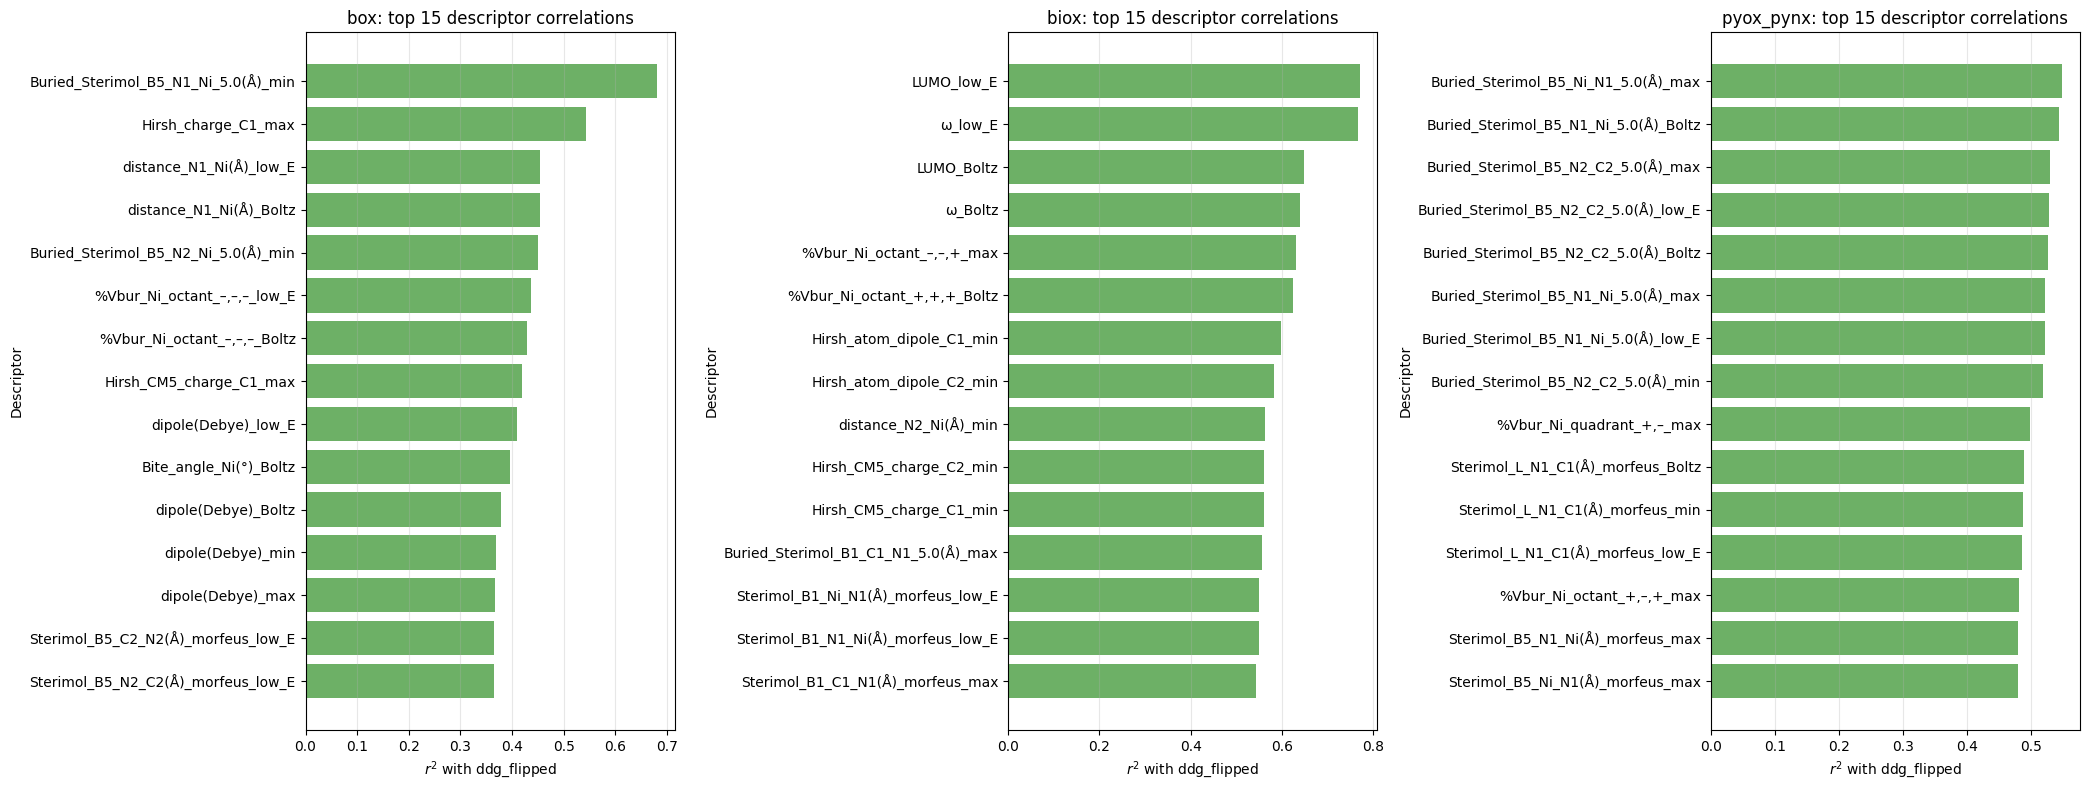

,sheet,x_column,correlation,abs_correlation,n_pairs,descriptor,r_squared
0,biox,x8,0.877680,0.877680,12,LUMO_low_E,7.703225e-01
1,biox,x20,-0.876034,0.876034,12,ω_low_E,7.674353e-01
2,biox,x5,0.804455,0.804455,12,LUMO_Boltz,6.471481e-01
3,biox,x17,-0.799869,0.799869,12,ω_Boltz,6.397899e-01
4,biox,x459,0.793695,0.793695,12,"%Vbur_Ni_octant_–,–,+_max",6.299512e-01
...,...,...,...,...,...,...,...
1558,pyox_pynx,x20,0.011699,0.011699,16,ω_low_E,1.368689e-04
1559,pyox_pynx,x59,-0.010717,0.010717,16,NBO_charge_N2_max,1.148485e-04
1560,pyox_pynx,x242,-0.010026,0.010026,16,Sterimol_L_Ni_N1(Å)_morfeus_min,1.005202e-04
1561,pyox_pynx,x491,-0.007459,0.007459,16,NMR_shift_C1_max,5.563332e-05


In [3]:
if "cs2_all_xi_correlations_named" not in globals():
    raise RuntimeError("Run Cell 4 first to compute CS2 correlation results.")

cs2_plot_top_n = 15
cs2_group_order = ["box", "biox", "pyox_pynx"]
fig, axes = plt.subplots(1, len(cs2_group_order), figsize=(7 * len(cs2_group_order), 8), sharex=False)
if len(cs2_group_order) == 1:
    axes = [axes]

for ax, group_name in zip(axes, cs2_group_order):
    plot_df = cs2_all_xi_correlations_named[cs2_all_xi_correlations_named["sheet"] == group_name].copy()
    plot_df = plot_df.sort_values(["r_squared", "correlation"], ascending=[False, False]).head(cs2_plot_top_n)
    plot_df = plot_df.sort_values("r_squared", ascending=True)

    ax.barh(plot_df["descriptor"], plot_df["r_squared"], color="#54a24b", alpha=0.85)
    ax.set_title(f"{group_name}: top {min(cs2_plot_top_n, len(plot_df))} descriptor correlations")
    ax.set_xlabel(r"$r^2$ with ddg_flipped")
    ax.set_ylabel("Descriptor")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

cs2_all_xi_correlations_named.sort_values(["sheet", "r_squared", "correlation"], ascending=[True, False, False]).reset_index(drop=True)

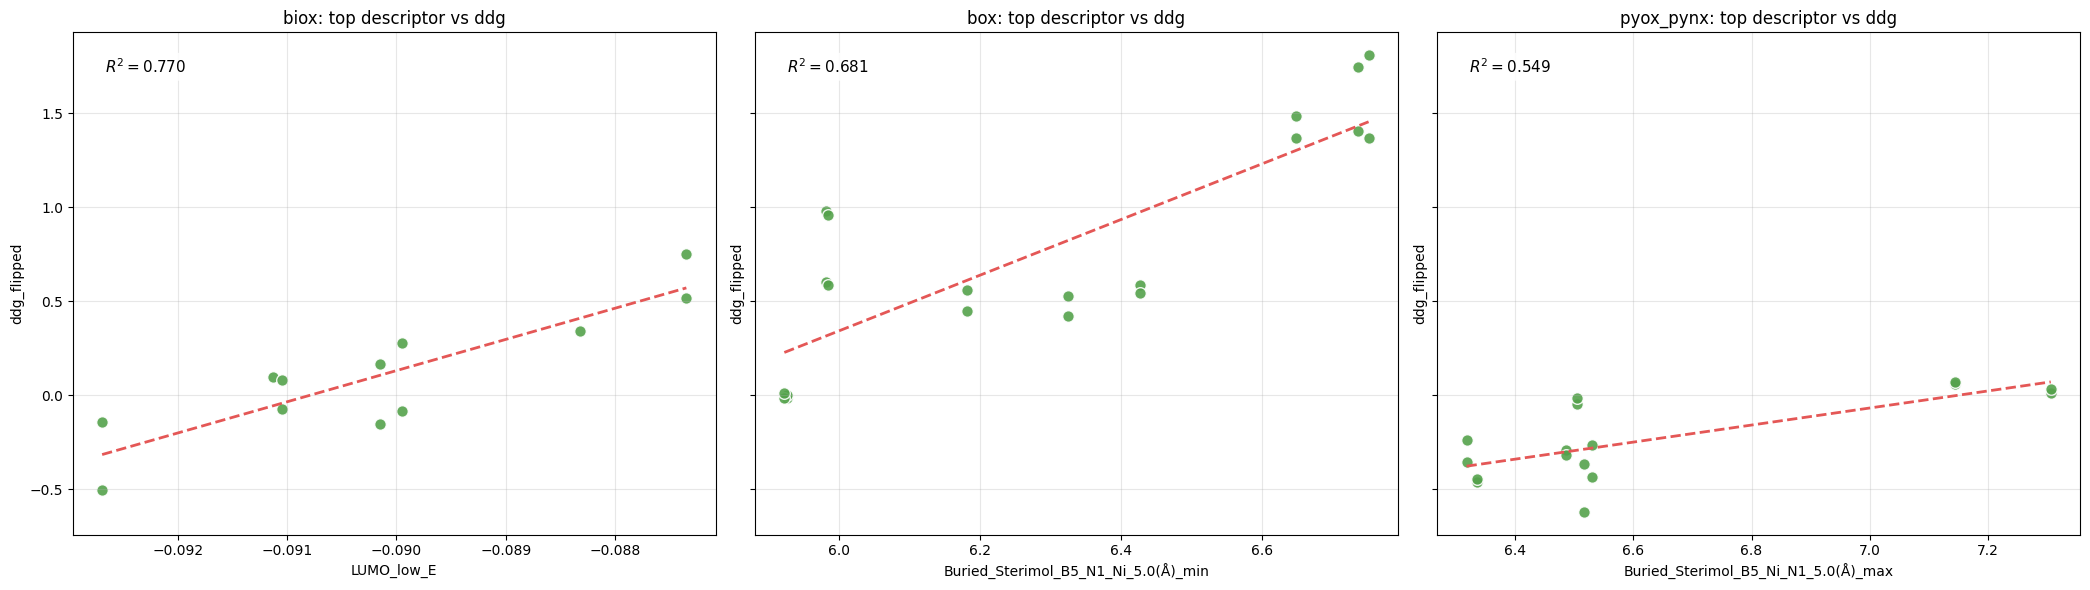

,sheet,x_column,descriptor,correlation,abs_correlation,n_pairs
0,biox,x8,LUMO_low_E,0.877680,0.877680,12
1,box,x298,Buried_Sterimol_B5_N1_Ni_5.0(Å)_min,0.825189,0.825189,20
2,pyox_pynx,x347,Buried_Sterimol_B5_Ni_N1_5.0(Å)_max,0.740734,0.740734,16


In [4]:
if "cs2_best_xi_by_group" not in globals() or "cs2_descriptor_name_map" not in globals():
    raise RuntimeError("Run Cells 4 and 5 first.")

cs2_top1_with_names = cs2_best_xi_by_group.merge(
    cs2_descriptor_name_map,
    on=["sheet", "x_column"],
    how="left",
)
cs2_top1_with_names["descriptor"] = cs2_top1_with_names["descriptor"].fillna(cs2_top1_with_names["x_column"])

fig, axes = plt.subplots(1, len(cs2_top1_with_names), figsize=(7 * len(cs2_top1_with_names), 6), sharey=True)
if len(cs2_top1_with_names) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, cs2_top1_with_names.iterrows()):
    group_name = row["sheet"]
    x_col = row["x_column"]
    descriptor_name = row["descriptor"]
    df = cs2_group_frames[group_name].copy()

    columns_lower = {str(col).strip().lower(): col for col in df.columns}
    ddg_col = columns_lower.get("ddg_flipped")
    plot_df = df[[x_col, ddg_col]].apply(pd.to_numeric, errors="coerce").dropna()

    ax.scatter(plot_df[x_col], plot_df[ddg_col], color="#54a24b", edgecolor="white", s=70, alpha=0.9)

    r_squared = np.nan
    if len(plot_df) >= 2:
        slope, intercept = np.polyfit(plot_df[x_col], plot_df[ddg_col], deg=1)
        x_fit = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, linestyle="--", color="#e45756", linewidth=2)
        correlation = plot_df[x_col].corr(plot_df[ddg_col])
        r_squared = correlation ** 2

    ax.text(
        0.05,
        0.95,
        rf"$R^2 = {r_squared:.3f}$" if not np.isnan(r_squared) else r"$R^2$ unavailable",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )

    ax.set_title(f"{group_name}: top descriptor vs ddg")
    ax.set_xlabel(descriptor_name)
    ax.set_ylabel("ddg_flipped")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

cs2_top1_with_names[["sheet", "x_column", "descriptor", "correlation", "abs_correlation", "n_pairs"]]